<a href="https://colab.research.google.com/github/jeffsgrover/Knitleader-scales/blob/main/KnitLeader_scales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import math

In [ ]:
class DashedImageDraw(ImageDraw.ImageDraw):

    def thick_line(self, xy, direction, fill=None, width=0):
        #xy – Sequence of 2-tuples like [(x, y), (x, y), ...]
        #direction – Sequence of 2-tuples like [(x, y), (x, y), ...]
        if xy[0] != xy[1]:
            self.line(xy, fill = fill, width = width)
        else:
            x1, y1 = xy[0]
            dx1, dy1 = direction[0]
            dx2, dy2 = direction[1]
            if dy2 - dy1 < 0:
                x1 -= 1
            if dx2 - dx1 < 0:
                y1 -= 1
            if dy2 - dy1 != 0:
                if dx2 - dx1 != 0:
                    k = - (dx2 - dx1)/(dy2 - dy1)
                    a = 1/math.sqrt(1 + k**2)
                    b = (width*a - 1) /2
                else:
                    k = 0
                    b = (width - 1)/2
                x3 = x1 - math.floor(b)
                y3 = y1 - int(k*b)
                x4 = x1 + math.ceil(b)
                y4 = y1 + int(k*b)
            else:
                x3 = x1
                y3 = y1 - math.floor((width - 1)/2)
                x4 = x1
                y4 = y1 + math.ceil((width - 1)/2)
            self.line([(x3, y3), (x4, y4)], fill = fill, width = 1)
        return

    def dashed_line(self, xy, dash=(2,2), fill=None, width=0):
        #xy – Sequence of 2-tuples like [(x, y), (x, y), ...]
        for i in range(len(xy) - 1):
            x1, y1 = xy[i]
            x2, y2 = xy[i + 1]
            x_length = x2 - x1
            y_length = y2 - y1
            length = math.sqrt(x_length**2 + y_length**2)
            dash_enabled = True
            postion = 0
            while postion <= length:
                for dash_step in dash:
                    if postion > length:
                        break
                    if dash_enabled:
                        start = postion/length
                        end = min((postion + dash_step - 1) / length, 1)
                        self.thick_line([(round(x1 + start*x_length),
                                          round(y1 + start*y_length)),
                                         (round(x1 + end*x_length),
                                          round(y1 + end*y_length))],
                                        xy, fill, width)
                    dash_enabled = not dash_enabled
                    postion += dash_step
        return

    def dashed_rectangle(self, xy, dash=(2,2), outline=None, width=0):
        #xy - Sequence of [(x1, y1), (x2, y2)] where (x1, y1) is top left corner and (x2, y2) is bottom right corner
        x1, y1 = xy[0]
        x2, y2 = xy[1]
        halfwidth1 = math.floor((width - 1)/2)
        halfwidth2 = math.ceil((width - 1)/2)
        min_dash_gap = min(dash[1::2])
        end_change1 = halfwidth1 + min_dash_gap + 1
        end_change2 = halfwidth2 + min_dash_gap + 1
        odd_width_change = (width - 1)%2
        self.dashed_line([(x1 - halfwidth1, y1), (x2 - end_change1, y1)],
                         dash, outline, width)
        self.dashed_line([(x2, y1 - halfwidth1), (x2, y2 - end_change1)],
                         dash, outline, width)
        self.dashed_line([(x2 + halfwidth2, y2 + odd_width_change),
                          (x1 + end_change2, y2 + odd_width_change)],
                         dash, outline, width)
        self.dashed_line([(x1 + odd_width_change, y2 + halfwidth2),
                          (x1 + odd_width_change, y1 + end_change2)],
                         dash, outline, width)
        return


In [ ]:
from re import L
# knitleader scale dimensions
# 1 3/16" x 27 3/4"
# 1 6/16" square on each end
dpi  = 300
mm_per_in = 25.4
cm_per_in = 2.54

w_in = 1+(3/16)
l_in = 27.75
w_px = int(w_in*dpi)
l_px = int(l_in*dpi)

cap_in = 1+6/16
cap_px = int(cap_in*dpi)

l_working_in = l_in-2*(cap_in)
l_working_px = int(l_working_in*dpi)

short_tick_len = 5   / mm_per_in * dpi  # 5 mm, converted to px
med_tick_len   = 7.5 / mm_per_in * dpi
long_tick_len  = 10  / mm_per_in * dpi

In [ ]:
# gauges
scales = {
    13:[128, 129, 130, 131],
    14:[132, 133, 134, 135],
    15:[136, 137, 138, 140],
    16:[142, 144, 146, 148],
    17:[150, 152, 154, 156],
    18:[158, 160, 162, 164],
    19:[166, 168, 170, 172],
    20:[174, 176, 178, 180]
}
# scales = {k:([(i, i/40, i/40*in_per_mm) for i in v]) for (k, v) in scales.items()}

# key represents label on scale
# value 0 represents millimeters per 40 sts (second label on scale)
# value 1 represents millimeters per stitch
# value 2 represents inches per stitch

In [ ]:
import pandas as pd
scales = pd.DataFrame(scales).melt()
scales.columns = ['label','width_40sts_mm']
scales['width_1st_mm'] = scales.width_40sts_mm/40
scales['width_1st_in'] = scales.width_1st_mm/mm_per_in
scales['width_1st_px'] = scales.width_1st_in*dpi
scales.head()

,label,width_40sts_mm,width_1st_mm,width_1st_in,width_1st_px
0,13,128,3.200,0.125984,37.795276
1,13,129,3.225,0.126969,38.090551
2,13,130,3.250,0.127953,38.385827
3,13,131,3.275,0.128937,38.681102
4,14,132,3.300,0.129921,38.976378


In [ ]:
# Mylar sheet goes out to 31.5 cm on either side of 0
# So if sheet is 27.75" wide, less 1 6/16 * 2 for end labels = 25" or 63.5cm of space in middle
# 31.5*2 = 63, so 5 mm of wiggle room
# All this to say: zero should be at 1 6/16" + 2.5mm from edge

# Add 37.8 px to left side of scale so it sits in KL properly
# Make sure BOTTOM of text is above halfway point

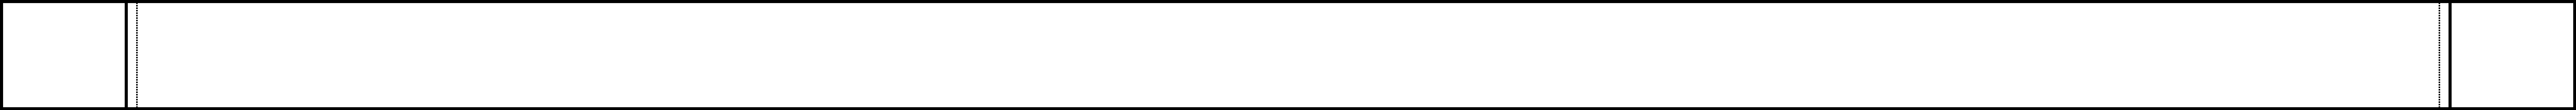

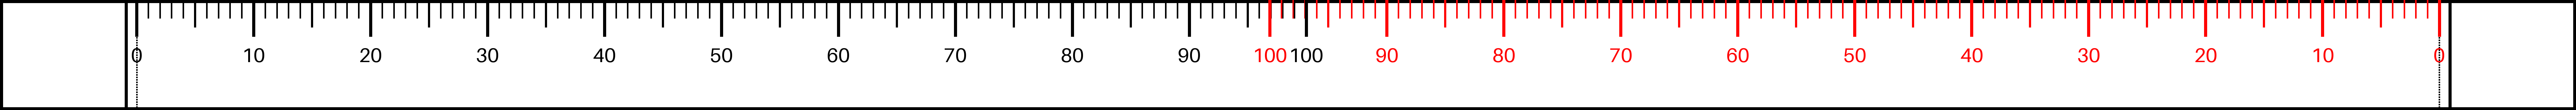

In [ ]:
im = Image.new(mode="RGB", size=(l_px, w_px), color="white")

draw = ImageDraw.Draw(im)
draw.rectangle([(0,0),(l_px,w_px)], fill='white', outline='black', width=10)
draw.rectangle([(0,0),(cap_px, w_px)], fill="white", outline="black", width=10)
draw.rectangle([(l_px-cap_px, 0),(l_px, w_px)], fill='white', outline='black', width=10)

zero_line_l_x = cap_px+(2.5/mm_per_in*dpi)
zero_line_r_x = l_px-zero_line_l_x

draw = DashedImageDraw(im)
draw.dashed_line([(zero_line_r_x, 0), (zero_line_r_x, w_px)], fill='black', dash=(5,3), width=5)
draw.dashed_line([(zero_line_l_x, 0), (zero_line_l_x, w_px)], fill='black', dash=(5,3), width=5)

max_num_sts = min(l_working_px/scales.width_1st_px[0], 100)
max_num_sts

i = 0
j = 0
r_x_temp = zero_line_r_x
l_x_temp = zero_line_l_x

while j < max_num_sts+1:
  if j%5>0:
    draw.line([(r_x_temp, 0), (r_x_temp, short_tick_len)], fill='red', width=5)
    draw.line([(l_x_temp, 0), (l_x_temp, short_tick_len)], fill='black', width=5)
  if (j%5==0) & (j%10>0):
    draw.line([(r_x_temp, 0), (r_x_temp, med_tick_len)],   fill='red', width=7)
    draw.line([(l_x_temp, 0), (l_x_temp, med_tick_len)],   fill='black', width=7)
  if j%10==0:
    draw.line([(r_x_temp, 0), (r_x_temp, long_tick_len)],  fill='red', width=10)
    draw.line([(l_x_temp, 0), (l_x_temp, long_tick_len)],  fill='black', width=10)
    draw.text((r_x_temp, long_tick_len*1.5), str(j),'red',   font_size=64, anchor='mm')
    draw.text((l_x_temp, long_tick_len*1.5), str(j),'black', font_size=64, anchor='mm')

  r_x_temp -= scales.width_1st_px[i]
  l_x_temp += scales.width_1st_px[i]
  j += 1

im

In [ ]:
im.save('sample_13.pdf','PDF',dpi=(dpi,dpi))